## Exploring Fancy Indexing

In [ ]:
import numpy as np
rand = np.random.RandomState(42)        # bu da random.seed() gibi tekrarlanabilirlik için kullanılıyor 
x = np.random.randint(100, size=10)
print(x)

[96 43 11 90 90 24 35 73 19 50]


In [4]:
print([x[3], x[7], x[2]])

[np.int32(90), np.int32(73), np.int32(11)]


In [5]:
ind = [3, 7, 5]
x[ind]

array([90, 73, 24], dtype=int32)

In [6]:
ind = np.array([[3, 7], [4, 5]])
x[ind]

array([[90, 73],
       [90, 24]], dtype=int32)

In [7]:
X = np.arange(12).reshape((3, 4))
X

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [9]:
row = np.array([0, 1, 2])
col = np.array([2, 1, 3])
X[row, col]

array([ 2,  5, 11])

In [10]:
X[row[:, np.newaxis], col]

array([[ 2,  1,  3],
       [ 6,  5,  7],
       [10,  9, 11]])

In [11]:
row[:, np.newaxis] * col

array([[0, 0, 0],
       [2, 1, 3],
       [4, 2, 6]])

### Combined Indexing

In [12]:
print(X)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [13]:
X[2, [2, 0, 1]]

array([10,  8,  9])

In [14]:
X[1:, [2, 0, 1]]

array([[ 6,  4,  5],
       [10,  8,  9]])

In [15]:
mask = np.array([1, 0, 1, 0], dtype=bool)
X[row[:, np.newaxis], mask]

array([[ 0,  2],
       [ 4,  6],
       [ 8, 10]])

###  Selecting Random Points

In [20]:
mean = [0, 0]
cov = [[1, 2], [2, 5]]
x = rand.multivariate_normal(mean, cov, 100)
x.shape

(100, 2)

In [24]:
import matplotlib.pyplot as plt 

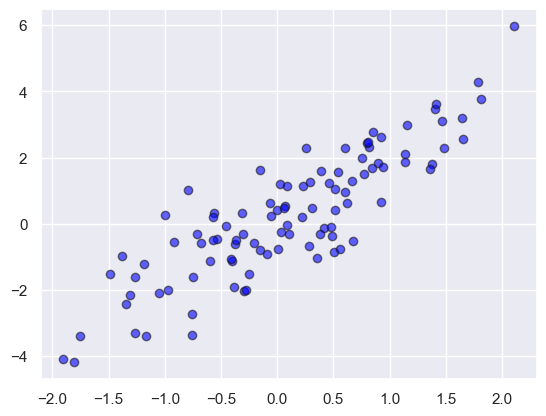

In [25]:
plt.scatter(x[:, 0], x[:, 1], color='blue', alpha=0.6, edgecolors='k')

### Modifying Values with Fancy Indexing

In [27]:
x = np.arange(10)
i = np.array([2, 1, 8, 4])

x[i] = 99
print(x)

[ 0 99 99  3 99  5  6  7 99  9]


In [28]:
x[i] -= 10

In [29]:
print(x)

[ 0 89 89  3 89  5  6  7 89  9]


In [30]:
x = np.zeros(10)
x[[0, 0]] = [4, 6]
print(x)

[6. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [31]:
i = [2, 3, 3, 4, 4, 4]
x[i] +=1
x

array([6., 0., 1., 1., 1., 0., 0., 0., 0., 0.])

In [32]:
x = np.zeros(10)
np.add.at(x, i, 1)
print(x)

[0. 0. 1. 2. 3. 0. 0. 0. 0. 0.]


### Binning Data

In [33]:
np.random.seed(42)
x = np.random.randn(100)

In [34]:
bins = np.linspace(-5, 5, 20)
counts = np.zeros_like(bins)

In [35]:
i = np.searchsorted(bins,x)

In [36]:
import matplotlib.pyplot as plt

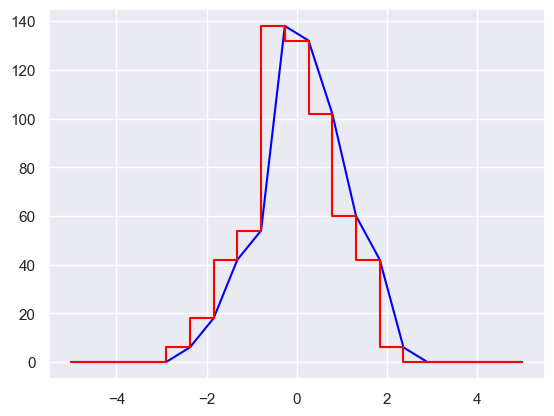

In [42]:
np.add.at(counts, i, 1)
plt.plot(bins, counts, color='blue')
plt.step(bins, counts, color='red')

### Sorting Arrays

- bu tarz döngü ile sıralamalar çok yavaş işliyor python veya numpy içindeki yerleşik (sort, argsort vb) kodlar çok daha hızlı 

In [1]:
import numpy as np

In [3]:
def selection_sort(x):
    for i in range(len(x)):
        swap =  i + np.argmin(x[i:])
        (x[i], x[swap]) = (x[swap], x[i])
    return x

x = np.array([2, 1, 4, 3, 5])
selection_sort(x)

array([1, 2, 3, 4, 5])

In [5]:
def bogosort(x):
    while np.any(x[:-1]> x[1:]):
        np.random.shuffle(x)
    return x
x = np.array([2, 1, 4, 3, 5])
bogosort(x)

array([1, 2, 3, 4, 5])

In [6]:
x = np.array([2, 1, 4, 3, 5])
x

array([2, 1, 4, 3, 5])

In [8]:
x.sort()
x

array([1, 2, 3, 4, 5])

In [11]:
x = np.array([2, 1, 4, 3, 5])
i = np.argsort(x)                  # sıralanmış elemanların indexlerini döner
print(i)
print(x[i])

[1 0 3 2 4]
[1 2 3 4 5]


### Sorting along rows or columns

In [12]:
rand = np.random.RandomState(42)
X = rand.randint(0, 10, (4, 6))
X

array([[6, 3, 7, 4, 6, 9],
       [2, 6, 7, 4, 3, 7],
       [7, 2, 5, 4, 1, 7],
       [5, 1, 4, 0, 9, 5]], dtype=int32)

In [ ]:
col = np.sort(X, axis=0)  # sütun boyunca sütundaki değerleri yukardan aşağı küçükten büyüğe doğru sıralar
col

array([[2, 1, 4, 0, 1, 5],
       [5, 2, 5, 4, 3, 7],
       [6, 3, 7, 4, 6, 7],
       [7, 6, 7, 4, 9, 9]], dtype=int32)

In [ ]:
row = np.sort(X) # satır boyunca sıralar küçükten büyüğe doğru
row

array([[3, 4, 6, 6, 7, 9],
       [2, 3, 4, 6, 7, 7],
       [1, 2, 4, 5, 7, 7],
       [0, 1, 4, 5, 5, 9]], dtype=int32)

### Partial Sorts: Partitioning

In [19]:
X = np.array([7, 3, 2, 1, 6, 5, 4])
np.partition(X, 3)                        # anladığım kadarıyla bir referans noktası veriyoruz ondan büyükler sağ tarafa küçükler sol tarafa sıralanıyor

array([1, 2, 3, 4, 5, 6, 7])